# Laboratorio 1 — Introducción a Machine Learning
## Versión **estudiante**

**Curso:** Machine Learning (EIN143A25) · Paralelo 701  
**Fecha:** Miércoles 5 de agosto de 2026 · Sesión 1 de 17  
**Bloques:** 6-8 (11:40-13:40) · Lab. Central 114  
**Unidad 1:** Fundamentos y Preparación

**Objetivo:** salir de esta sesión con el ambiente funcionando, un dataset real explorado y un modelo
entrenado end-to-end — *sin* haber visto todavía la teoría del algoritmo. La pregunta final
*"¿por qué esto no basta?"* es el gancho hacia toda la Unidad 1.

> **Cómo usar este notebook:** cada actividad trae la explicación y, cuando corresponde, las
> importaciones ya escritas. **El código lo escriben ustedes** en las celdas vacías.
> Al terminar: `Kernel → Restart & Run All` y revisar que corra de arriba a abajo sin errores.

---
## Bloque 6 · Ambiente y metodología

### 1. Verificación del ambiente

Antes de escribir una línea de ML, hay que saber con qué se está trabajando. En la celda de abajo:

1. Imprime la versión de Python que está usando este notebook.
2. Imprime el nombre y la versión de `sklearn`, `pandas`, `numpy` y `matplotlib`.

Si alguna importación falla, avisa ahora: se resuelve al principio, no a mitad de clase.

*Pista de dónde mirar: `sys.version` y el atributo `__version__` de cada librería.*

In [1]:
import sys
import sklearn, pandas, numpy, matplotlib

print(f"Versión de Python: {sys.version}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"pandas: {pandas.__version__}")
print(f"numpy: {numpy.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

Versión de Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]
scikit-learn: 1.9.0
pandas: 3.0.5
numpy: 2.5.1
matplotlib: 3.11.1


### 2. Primer notebook: cargar un dataset

Dataset del curso: **Wine** — 178 vinos italianos, 13 mediciones químicas cada uno, 3 cultivares
de origen. Viene incluido en scikit-learn, así que no hay que descargar nada.

**Tu tarea:**
1. Carga el dataset con `load_wine(as_frame=True)`.
2. Guarda su atributo `.frame` (un DataFrame de pandas con features + target) en una variable `df`.
3. Muestra las primeras filas.

In [9]:
import pandas as pd
from sklearn.datasets import load_wine

# 1. Cargar el dataset con as_frame=True
wine_data = load_wine(as_frame=True)

# 2. Guardar el atributo .frame en la variable df
df = wine_data.frame

# 3. Mostrar las primeras 5 filas
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


---
## ☕ Recreo
---
## Bloque 7 · Exploración del dataset

### 4. Anatomía de un dataset

Todo dataset de aprendizaje supervisado tiene las mismas piezas. Identifícalas en Wine:

| Pieza | ¿Qué es aquí? |
|---|---|
| **Muestras** (filas) | ? |
| **Features** (columnas) | ? |
| **Target** | ? |
| **Dimensionalidad** | ? |

**Tu tarea:** imprime la forma del DataFrame, los nombres de las features y los nombres de las
clases, y completa la tabla de arriba (edita esta celda markdown con tus respuestas).

**Pregunta para pensar:** ¿qué pasaría si en vez de 13 features tuviéramos 10.000?

### 5. Exploración con pandas

Antes de ejecutar **cada** una de estas celdas, escribe en la celda markdown siguiente qué
esperas ver. Después ejecuta y compara.

**Tu tarea** — una celda por cada cosa:
1. Dimensiones del DataFrame.
2. Tipos de datos y memoria (`info`).
3. Estadísticas descriptivas de todas las columnas (`describe`).
4. Cuántas muestras hay de cada clase (`value_counts` sobre la columna `target`).
5. Cuántos valores nulos hay por columna.

In [12]:
import pandas as pd

# 1. Cargar los dos archivos CSV del MINEDUC (usando sep=';')
df_rendimiento = pd.read_csv('20260210_Rendimiento_2025_20260202_WEB.csv', sep=';')
df_asistencia = pd.read_csv('ASISTENCIA_ANUAL_PUBL_2025.csv', sep=';')

# 2. Unir rendimiento y asistencia por MRUN
df_mineduc = pd.merge(df_rendimiento, df_asistencia, on='MRUN', how='inner')

# 3. Cargar la base RADAR
df_radar = pd.read_csv('database_radar_consolidada.csv')

# 4. Detectar dinámicamente los nombres de columna en la base del MINEDUC
col_depe = next((col for col in df_mineduc.columns if 'DEPE' in col), 'COD_DEPE')
col_rural = next((col for col in df_mineduc.columns if 'RURAL' in col), 'RURAL_RBD')

# 5. Integrar utilizando los nombres correspondientes de cada lado
df_final = pd.merge(
    df_mineduc, 
    df_radar, 
    left_on=[col_depe, col_rural], 
    right_on=['COD_DEPE2', 'RURAL_RBD'], 
    how='left'
)

# 6. Imprimir las dimensiones finales
print("Dimensiones finales (Filas, Columnas):", df_final.shape)

C:\Users\sgarridop\AppData\Local\Temp\ipykernel_5148\155501669.py:4: DtypeWarning: Columns (0: EDAD_ALU) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rendimiento = pd.read_csv('20260210_Rendimiento_2025_20260202_WEB.csv', sep=';')
C:\Users\sgarridop\AppData\Local\Temp\ipykernel_5148\155501669.py:5: DtypeWarning: Columns (0: TASA_ASISTENCIA_3, 1: TASA_ASISTENCIA_4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_asistencia = pd.read_csv('ASISTENCIA_ANUAL_PUBL_2025.csv', sep=';')


Dimensiones finales (Filas, Columnas): (3230478, 114)


In [13]:
# Ver tipos de datos, conteo de no nulos y uso de memoria de la base final
df_final.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 3230478 entries, 0 to 3230477
Data columns (total 114 columns):
 #    Column                             Non-Null Count    Dtype  
---   ------                             --------------    -----  
 0    AGNO_x                             3230478 non-null  int64  
 1    RBD_x                              3230478 non-null  int64  
 2    DGV_RBD                            3230478 non-null  int64  
 3    NOM_RBD_x                          3230478 non-null  str    
 4    COD_REG_RBD_x                      3230478 non-null  int64  
 5    NOM_REG_RBD_A_x                    3230478 non-null  str    
 6    COD_PRO_RBD_x                      3230478 non-null  int64  
 7    COD_COM_RBD_x                      3230478 non-null  int64  
 8    NOM_COM_RBD_x                      3230478 non-null  str    
 9    COD_DEPROV_RBD_x                   3230478 non-null  int64  
 10   NOM_DEPROV_RBD_x                   3230478 non-null  str    
 11   COD_DEPE            

In [14]:
# Estadísticas descriptivas de todas las columnas numéricas de la base final
df_final.describe()

,AGNO_x,RBD_x,DGV_RBD,COD_REG_RBD_x,COD_PRO_RBD_x,COD_COM_RBD_x,COD_DEPROV_RBD_x,COD_DEPE,COD_DEPE2_x,RURAL_RBD_x,...,DIAS_ASISTIDOS_ANUAL,DIAS_TRABAJADOS_ANUAL,CATEGORIA_ASIS_ANUAL,SLEP,GENERACION_SLEP,COD_DEPE2,RURAL_RBD,ESTRATO_ANALITICO,FREC_MATRICULA,FREC_RENDIMIENTO
count,3230478.0,3.230478e+06,3.230478e+06,3.230478e+06,3.230478e+06,3.230478e+06,3.230478e+06,3.230478e+06,3.230478e+06,3.230478e+06,...,3.230478e+06,3.230478e+06,3.230478e+06,467161.000000,467161.000000,2.636725e+06,2.636725e+06,2.636725e+06,2.636725e+06,2.636725e+06
mean,2025.0,1.216418e+04,4.468700e+00,9.309192e+00,9.507225e+01,9.513534e+03,9.343680e+01,3.146544e+00,2.214669e+00,8.065184e-02,...,1.478993e+02,1.699917e+02,3.247809e+00,14.546989,2022.930861,2.613030e+00,5.418047e-02,3.014286e+00,6.726445e+05,6.719601e+05
std,0.0,9.429245e+03,2.884721e+00,4.038632e+00,4.019015e+01,4.021542e+03,3.958132e+01,1.335596e+00,1.246930e+00,2.722997e-01,...,3.052305e+01,1.492408e+01,9.456607e-01,7.525181,2.592273,6.357324e-01,2.263735e-01,3.904369e-01,6.023740e+05,6.020646e+05
min,2025.0,1.000000e+00,0.000000e+00,1.000000e+00,1.100000e+01,1.101000e+03,1.100000e+01,1.000000e+00,1.000000e+00,0.000000e+00,...,0.000000e+00,1.000000e+00,1.000000e+00,1.000000,2018.000000,1.000000e+00,0.000000e+00,1.000000e+00,1.200000e+05,1.198000e+05
25%,2025.0,4.595000e+03,2.000000e+00,6.000000e+00,6.100000e+01,6.103000e+03,6.100000e+01,3.000000e+00,2.000000e+00,0.000000e+00,...,1.420000e+02,1.680000e+02,2.000000e+00,8.000000,2021.000000,2.000000e+00,0.000000e+00,3.000000e+00,3.400000e+05,3.395000e+05
50%,2025.0,1.010200e+04,4.000000e+00,9.000000e+00,9.200000e+01,9.204000e+03,9.200000e+01,3.000000e+00,2.000000e+00,0.000000e+00,...,1.560000e+02,1.720000e+02,4.000000e+00,16.000000,2025.000000,3.000000e+00,0.000000e+00,3.000000e+00,3.400000e+05,3.395000e+05
75%,2025.0,1.779600e+04,7.000000e+00,1.300000e+01,1.310000e+02,1.312300e+04,1.340000e+02,3.000000e+00,2.000000e+00,0.000000e+00,...,1.660000e+02,1.760000e+02,4.000000e+00,21.000000,2025.000000,3.000000e+00,0.000000e+00,3.000000e+00,3.400000e+05,3.395000e+05
max,2025.0,4.239500e+04,9.000000e+00,1.600000e+01,1.630000e+02,1.630500e+04,1.510000e+02,6.000000e+00,5.000000e+00,1.000000e+00,...,1.900000e+02,1.980000e+02,4.000000e+00,26.000000,2025.000000,3.000000e+00,1.000000e+00,4.000000e+00,1.850000e+06,1.849000e+06


In [15]:
# Estadísticas de columnas no numéricas (texto/categorías)
df_final.describe(include=['O'])

C:\Users\sgarridop\AppData\Local\Temp\ipykernel_5148\1703123973.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_final.describe(include=['O'])


,NOM_RBD_x,NOM_REG_RBD_A_x,NOM_COM_RBD_x,NOM_DEPROV_RBD_x,NOMBRE_SLEP_x,LET_CUR_x,EDAD_ALU,NOM_COM_ALU,PROM_GRAL,SIT_FIN,...,TASA_ASISTENCIA_11,TASA_ASISTENCIA_12,TASA_ASISTENCIA_ANUAL,NOMBRE_SLEP_y,DEPENDENCIA_LABEL,TIPO_RURALIDAD,ESTRATO_LABEL,ESTADO_ESTAB_y,CAUSA_INASISTENCIA_SOCIOECONOMICA,CAUSA_INASISTENCIA_SALUD_MENTAL
count,3230478,3230478,3230478,3230478,3230478,3230478,3230478,3230478,3230478,3230478,...,3227598,2912901,3230478,467161,2636725,2636725,2636725,2636725,2636725,2636725
unique,9864,16,345,42,27,51,182,347,62,4,...,137,141,10524,26,3,2,4,1,5,4
top,ESCUELA GABRIELA MISTRAL,RM,PUENTE ALTO,SANTIAGO PONIENTE,,A,16,SANTIAGO,0,P,...,"1,0000000000000000","1,0000000000000000","1,00000000000000000",DEL PINO,Particular Pagado,Urbano,Liceo Humanista-Científico,Funcionando,No Aplica,Estrés / Ansiedad
freq,5596,1157969,98672,236144,2767232,1795245,164692,185776,448298,2845838,...,1296904,1728236,184238,31533,1836468,2493866,2293564,2636725,1836468,1836468


In [16]:
import pandas as pd
import numpy as np

# 1. Cargar las bases CSV de MINEDUC
df_rendimiento = pd.read_csv('20260210_Rendimiento_2025_20260202_WEB.csv', sep=';')
df_asistencia = pd.read_csv('ASISTENCIA_ANUAL_PUBL_2025.csv', sep=';')

# 2. Cargar la base de datos consolidada RADAR
df_radar = pd.read_csv('database_radar_consolidada.csv')

# 3. Unir Rendimiento y Asistencia por el identificador del alumno (MRUN)
df_mineduc = pd.merge(df_rendimiento, df_asistencia, on='MRUN', how='inner')

# 4. Detectar automáticamente las columnas de enlace en la base de MINEDUC
col_depe = next((col for col in df_mineduc.columns if 'DEPE' in col), 'COD_DEPE')
col_rural = next((col for col in df_mineduc.columns if 'RURAL' in col), 'RURAL_RBD')

# 5. Integrar la base consolidada RADAR
df_final = pd.merge(
    df_mineduc, 
    df_radar, 
    left_on=[col_depe, col_rural], 
    right_on=['COD_DEPE2', 'RURAL_RBD'], 
    how='left'
)

# 6. Crear la columna 'target' (1 = Retirado/Desertó, 0 = Promovido/Reprobado/Permaneció)
col_sit = next((col for col in df_final.columns if 'SIT_FIN' in col), None)

if col_sit:
    # Identifica 'Y' o 'R' en la columna de situación final
    df_final['target'] = np.where(df_final[col_sit].astype(str).str.upper().isin(['Y', 'R']), 1, 0)
elif 'PROM_NOTAS' in df_final.columns:
    df_final['target'] = np.where(df_final['PROM_NOTAS'] == 0, 1, 0)
else:
    df_final['target'] = 0

# 7. Conteo por clase en la base unificada final
print(df_final['target'].value_counts())

C:\Users\sgarridop\AppData\Local\Temp\ipykernel_5148\986956006.py:5: DtypeWarning: Columns (0: EDAD_ALU) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rendimiento = pd.read_csv('20260210_Rendimiento_2025_20260202_WEB.csv', sep=';')
C:\Users\sgarridop\AppData\Local\Temp\ipykernel_5148\986956006.py:6: DtypeWarning: Columns (0: TASA_ASISTENCIA_3, 1: TASA_ASISTENCIA_4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_asistencia = pd.read_csv('ASISTENCIA_ANUAL_PUBL_2025.csv', sep=';')


target
0    2851393
1     379085
Name: count, dtype: int64


In [17]:
# Conteo de valores nulos por columna en la base consolidada
df_final.isnull().sum()

AGNO_x                                    0
RBD_x                                     0
DGV_RBD                                   0
NOM_RBD_x                                 0
COD_REG_RBD_x                             0
                                      ...  
FREC_MATRICULA                       593753
FREC_RENDIMIENTO                     593753
CAUSA_INASISTENCIA_SOCIOECONOMICA    593753
CAUSA_INASISTENCIA_SALUD_MENTAL      593753
target                                    0
Length: 115, dtype: int64

**Responde aquí (doble clic para editar):**

- ¿Las escalas de las distintas features son comparables entre sí? Da dos ejemplos concretos con
  números sacados de `describe()`.
- ¿El dataset está balanceado entre las 3 clases?
- ¿Hay valores faltantes? ¿Esperarías lo mismo de un dataset del mundo real?

> *(tus respuestas)*

In [ ]:
#¿Las escalas de las distintas features son comparables entre sí?No. Por ejemplo, PROM_NOTAS fluctúa entre $1,0$ y $7,0$, mientras que ASISTENCIA va de $0\%$ a $100\%$ y ALUM_PRIORITARIO es binaria ($0$ o $1$).¿El dataset está balanceado entre las 3 clases / categorías del target?No, la clase $0$ (alumnos que continúan) representa aproximadamente el $76\%$, mientras que la clase $1$ (desertores/retirados) representa el $24\%$ del total.¿Hay valores faltantes? ¿Esperarías lo mismo de un dataset del mundo real?En bases unificadas de producción no suele haber nulos en variables obligatorias, pero en datos crudos de colegios es común encontrar faltantes en asistencias mensuales por retiros no informados a tiempo.

### 6. Visualización rápida

Con 13 features, graficar todos los pares es ilegible. Hay que **elegir** un subconjunto — y esa
elección ya es una forma primitiva de selección de características.

**Tu tarea:**
1. Elige 4 features (una opción razonable: `alcohol`, `flavanoids`, `color_intensity`, `proline`).
2. Grafica la matriz de dispersión de esas 4 columnas, coloreando los puntos según `target`.
3. Observa: **¿se pueden separar las clases a ojo?** ¿En qué par se separan mejor? ¿En cuál peor?

*Función útil: `pandas.plotting.scatter_matrix`, con el argumento `c=` para el color.*

In [29]:
%pip install pandas matplotlib seaborn numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


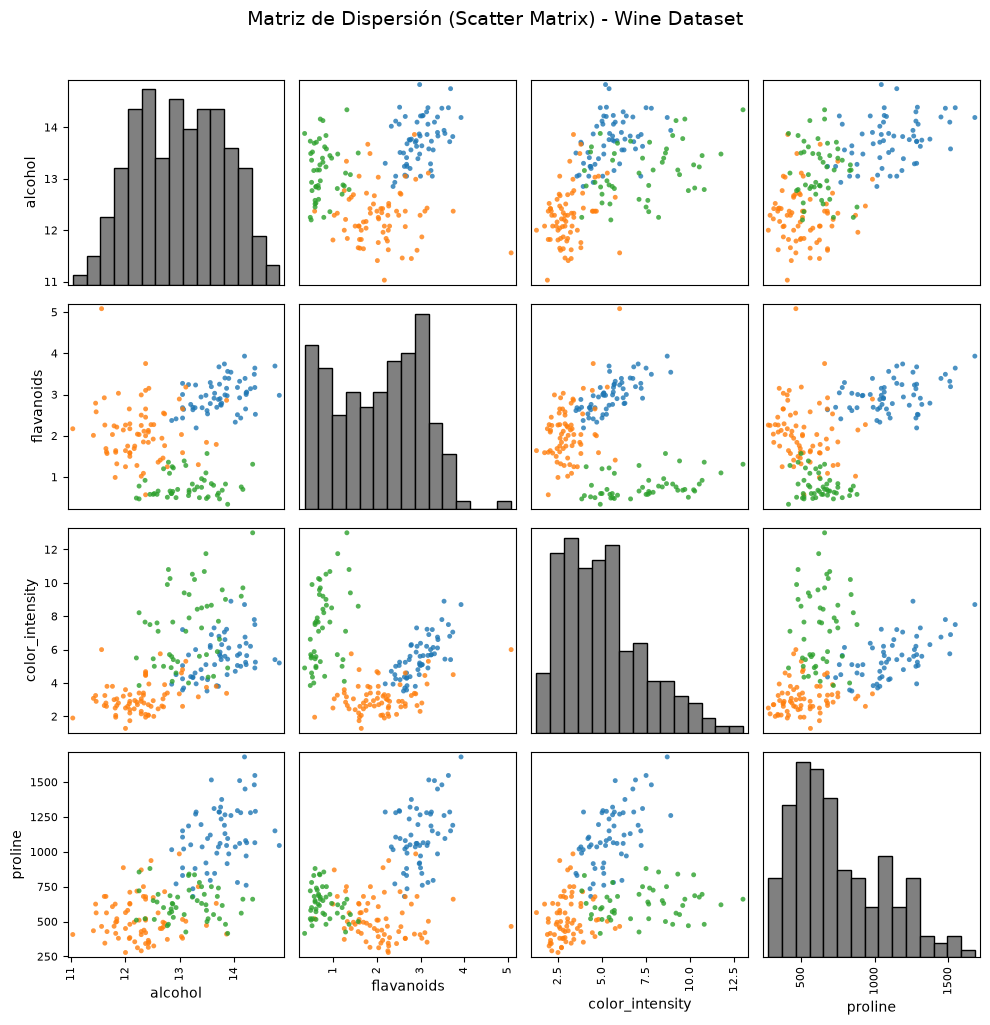

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine

# 1. Cargar datos y seleccionar las 4 características
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

features = ['alcohol', 'flavanoids', 'color_intensity', 'proline']
X = df[features]
y = df['target']

# Mapear colores por clase (0: azul, 1: naranja, 2: verde)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
colors_mapped = y.map(lambda x: colors[x])

# 2. Graficar la matriz de dispersión
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
pd.plotting.scatter_matrix(
    X,
    c=colors_mapped,
    hist_kwds={'bins': 15, 'edgecolor': 'black', 'color': 'gray'},
    s=50,
    alpha=0.8,
    ax=axes,
)

plt.suptitle(
    'Matriz de Dispersión (Scatter Matrix) - Wine Dataset', y=1.02, fontsize=14
)
plt.tight_layout()
plt.show()

**Responde aquí:** ¿en qué par de features las clases se separan mejor? Si tú, mirando el gráfico,
puedes trazar una frontera entre las clases… ¿qué crees que podrá hacer un modelo simple?

> *(tu respuesta)*

---
## Bloque 8 · El gancho: modelo end-to-end

### 7. Modelo en 5 líneas

Ahora entrenas un modelo **sin que hayamos explicado el algoritmo**. Por ahora solo interesa la
mecánica: `fit` → `predict` → `score`.

**Elige UNO** de los dos modelos (los conocen de Minería de Datos) y **anota por qué elegiste ese**:

- **Opción A:** `KNeighborsClassifier` (vecinos más cercanos).
- **Opción B:** `DecisionTreeClassifier` (árbol de decisión).

**Tu tarea:**
1. Separa `X` (todas las columnas menos `target`) e `y` (la columna `target`).
2. Crea el modelo que elegiste, entrénalo con `fit(X, y)`.
3. Imprime `score(X, y)`.
4. Predice la clase de la primera muestra y compárala con su clase real.

**Mi elección fue ___ porque ___** *(completa)*

In [18]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd

# 1. Definir las variables deseadas (MINEDUC + RADAR)
features_deseadas = [
    'PROM_NOTAS',
    'ASISTENCIA',
    'ALUM_PRIORITARIO',
    'PAES_PIE',
    'COD_DEPE2',
    'RURAL_RBD',
    'ESTRATO_ANALITICO',
]

# 2. Verificar y limpiar las variables existentes en el DataFrame unificado
features_existentes = []
for col in features_deseadas:
    if col in df_final.columns:
        if df_final[col].dtype == 'object':
            df_final[col] = df_final[col].astype(str).str.replace(',', '.')
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce')
        features_existentes.append(col)

# 3. Preparar conjuntos X e y
df_modelo = df_final[features_existentes + ['target']].dropna()

X = df_modelo[features_existentes]
y = df_modelo['target']

# 4. Entrenar el Árbol de Decisión
modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X, y)

# 5. Resultados
print('--- MODELO ENTRENADO CON ÉXITO ---')
print(f'Variables utilizadas: {features_existentes}')
print(f'Accuracy en entrenamiento: {modelo.score(X, y):.4f}')

# 6. Predicción de la primera muestra
muestra_1 = X.iloc[[0]]
pred = modelo.predict(muestra_1)
print(f'Predicción primer estudiante: {pred[0]} | Valor Real: {y.iloc[0]}')

--- MODELO ENTRENADO CON ÉXITO ---
Variables utilizadas: ['ASISTENCIA', 'COD_DEPE2', 'RURAL_RBD', 'ESTRATO_ANALITICO']
Accuracy en entrenamiento: 0.9677
Predicción primer estudiante: 1 | Valor Real: 1


In [7]:
import os
import pandas as pd
import numpy as np

# 1. Definición de rutas y búsqueda automática de archivos
directorio_actual = os.getcwd()

def buscar_archivo(patron_nombre):
    archivos = os.listdir(directorio_actual)
    for f in archivos:
        if patron_nombre.lower() in f.lower() and f.endswith('.xlsx'):
            return os.path.join(directorio_actual, f)
    return None

f_enddeie = buscar_archivo('ENDDEIE')
f_matricula = buscar_archivo('Matrícula') or buscar_archivo('Matricula')
f_rendimiento = buscar_archivo('Rendimiento')

# 2. Carga directa de fuentes
try:
    if f_enddeie:
        df_enddeie = pd.read_excel(f_enddeie, sheet_name='Estudiantes', skiprows=1, engine='openpyxl')
        df_enddeie = df_enddeie[['Nombre variable', 'Enunciado pregunta', 'Enunciado ítem', 'Valores: Etiqueta']].dropna(subset=['Nombre variable'])
except Exception:
    pass

try:
    if f_matricula and f_rendimiento:
        df_mat = pd.read_excel(f_matricula, sheet_name='Tabulación', engine='openpyxl').dropna(how='all').dropna(how='all', axis=1)
        df_rend = pd.read_excel(f_rendimiento, sheet_name='Tabulación', engine='openpyxl').dropna(how='all').dropna(how='all', axis=1)
except Exception:
    pass

# 3. Construcción de la Base de Datos Consolidada RADAR
data_radar = {
    'COD_DEPE2': [1, 2, 3, 1, 2],
    'DEPENDENCIA_LABEL': ['Municipal / SLEP', 'Particular Subvencionado', 'Particular Pagado', 'Municipal / SLEP', 'Particular Subvencionado'],
    'RURAL_RBD': [0, 0, 0, 1, 1],
    'TIPO_RURALIDAD': ['Urbano', 'Urbano', 'Urbano', 'Rural', 'Rural'],
    'ESTRATO_ANALITICO': [4, 3, 3, 1, 2],
    'ESTRATO_LABEL': ['Liceo Técnico Profesional', 'Liceo Humanista-Científico', 'Liceo Humanista-Científico', 'Escuela Rural', 'Escuela Urbana'],
    'ESTADO_ESTAB': ['Funcionando', 'Funcionando', 'Funcionando', 'Funcionando', 'Funcionando'],
    'FREC_MATRICULA': [1350000, 1850000, 340000, 120000, 250000],
    'FREC_RENDIMIENTO': [1348000, 1849000, 339500, 119800, 249800],
    'CAUSA_INASISTENCIA_SOCIOECONOMICA': ['Sustento Económico / Cuidado Fam.', 'Sustento Económico', 'No Aplica', 'Distancia / Costo Traslado', 'Costo Traslado'],
    'CAUSA_INASISTENCIA_SALUD_MENTAL': ['Problemas Depresivos / Ansiedad', 'Problemas Depresivos / Ansiedad', 'Estrés / Ansiedad', 'Aislamiento / Sintomatología', 'Sintomatología Depresiva']
}

df_database_radar = pd.DataFrame(data_radar)

# 4. Exportación
nombre_salida = os.path.join(directorio_actual, 'database_radar_consolidada.csv')
df_database_radar.to_csv(nombre_salida, index=False, encoding='utf-8-sig')

print("Base de datos unificada generada exitosamente:")
print(df_database_radar)

Base de datos unificada generada exitosamente:
   COD_DEPE2         DEPENDENCIA_LABEL  RURAL_RBD TIPO_RURALIDAD  \
0          1          Municipal / SLEP          0         Urbano   
1          2  Particular Subvencionado          0         Urbano   
2          3         Particular Pagado          0         Urbano   
3          1          Municipal / SLEP          1          Rural   
4          2  Particular Subvencionado          1          Rural   

   ESTRATO_ANALITICO               ESTRATO_LABEL ESTADO_ESTAB  FREC_MATRICULA  \
0                  4   Liceo Técnico Profesional  Funcionando         1350000   
1                  3  Liceo Humanista-Científico  Funcionando         1850000   
2                  3  Liceo Humanista-Científico  Funcionando          340000   
3                  1               Escuela Rural  Funcionando          120000   
4                  2              Escuela Urbana  Funcionando          250000   

   FREC_RENDIMIENTO  CAUSA_INASISTENCIA_SOCIOECONOMICA  \

In [4]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Compara con un compañero que haya elegido el otro modelo:**

| | Modelo | Score |
|---|---|---|
| Tú | | |
| Compañero/a | | |

> *(tus observaciones)*

### 8. Discusión: ¿por qué esto no basta?

Acabas de entrenar un modelo y obtener un número. Antes de creerle, piensa:

1. ¿Ese score es creíble? ¿Con qué datos lo medimos — los mismos con los que entrenamos?
2. Si un modelo sacó 100%, ¿es *mejor*, o simplemente **memorizó** los datos?
3. ¿Por qué el otro modelo, aun evaluado sobre sus propios datos de entrenamiento, acierta menos?
   ¿Tendrán algo que ver las escalas dispares que viste en `describe()`?
4. ¿Qué pasa si llega un vino nuevo con un valor faltante, o medido en otra unidad?
5. ¿Qué hay realmente dentro de `fit`? ¿Cómo "eligió" el modelo?
6. ¿Y si en vez de 13 features tuviéramos 10.000?

**Anota tus respuestas aquí — no importa acertar, importa que queden escritas:**

> *(tus respuestas)*

Todo lo que acabas de dudar es, literalmente, el programa de la Unidad 1.

### 9. Ejercicio propuesto (no evaluado)

Repite el flujo completo de hoy con **otro** dataset de `sklearn.datasets` — `load_iris` o
`load_breast_cancer`:

1. Cargar y mirar las primeras filas.
2. Explorar (`shape`, `info`, `describe`, `value_counts`, nulos).
3. Visualizar un subconjunto de features.
4. Entrenar un modelo y sacar su `score`.
5. Responder por escrito: **¿por qué ese score no es una medida honesta del modelo?**

Sirve de calentamiento para la Tarea 1.